In [8]:
import sys
sys.path.append('../')
import os
import torch
from dotenv import load_dotenv
import LLMP as L

# Clear CUDA cache if using GPU
torch.cuda.empty_cache()

# Set the device to CPU (if needed)
device = torch.device("cpu")

# Load environment variables from the .env file
load_dotenv()

# Create instances of the Gemini models
gpt4vision = L.GPTModel("gpt-4-vision-preview")
gpt4o = L.GPTModel("gpt-4o")
gemini1 = L.GeminiProVision()  
gemini2 = L.Gemini1_5Flash() 

# Add them to a dictionary for easy access
model_instances = {
    "gpt4o": gpt4o,
    "gpt4vision": gpt4vision,
    "LLaVA": L.LLaVA(),  
    "CustomLLaVA": L.CustomLLaVA(),  
    "GeminiProVision": gemini1,  
    "Gemini1_5Flash": gemini2
}
    

Initializing GPTModel with model_name: gpt-4-vision-preview
Initializing GPTModel with model_name: gpt-4o


In [7]:
# Define your query and images
query = "What do you see? If you see a line, estimate its direction in degrees (0 to 360). Respond with a numerical range not larger than 10 degrees (e.g., 180-190). Include only the range without any additional text."
images = [L.GPImage.figure1('direction') for i in range(10)]

# Run the evaluator
result1 = L.Evaluator.run(images, query, model_instances)

Initializing GPTModel with model_name: gpt-4-vision-preview
Initializing GPTModel with model_name: gpt-4o


/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100%|█████████████████████████████████████████| 2/2 [00:05<00:00,  2.76s/it]
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/t

In [2]:
result1 =  {'gt': [129, 229, 187, 28, 27, 234, 124, 210, 323, 259], 'gpt4o': {'raw_answers': ['120-130', '30-40', '80-90', '50-60', '50-60', '120-130', '110-120', '60-70', '300-310', '60-70'], 'parsed_answers': [[120.0, 130.0], [30.0, 40.0], [80.0, 90.0], [50.0, 60.0], [50.0, 60.0], [120.0, 130.0], [110.0, 120.0], [60.0, 70.0], [300.0, 310.0], [60.0, 70.0]], 'mean': 103.0, 'std': 73.72923436466705, 'mse': 12051.6, 'mlae': 13.018917348292995, 'times': [727.0815372467041, 1072.218418121338, 742.847204208374, 973.5305309295654, 693.0363178253174, 929.3386936187744, 665.1058197021484, 690.9255981445312, 821.6719627380371, 820.3120231628418], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['330-340', '45-55', '90-100', '45-55', '45-55', '45-55', '310-320', '45-55', '45-55', '0-10'], 'parsed_answers': [[330.0, 340.0], [45.0, 55.0], [90.0, 100.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0], [310.0, 320.0], [45.0, 55.0], [45.0, 55.0], [0.0, 10.0]], 'mean': 105.0, 'std': 111.91514642799696, 'mse': 31893.6, 'mlae': 13.951296099826099, 'times': [924.135684967041, 865.4072284698486, 1365.3759956359863, 996.9818592071533, 965.0285243988037, 1171.374797821045, 997.2164630889893, 799.4003295898438, 963.1106853485107, 878.8332939147949], 'forced_repetitions': 0}, 'LLaVA': {'raw_answers': ['180-190', '180-190', '180-190', '180-190', '180-190', '180-190', '180-190', '180-190', '180-190', '180-190'], 'parsed_answers': [[180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0]], 'mean': 185.0, 'std': 0.0, 'mse': 8595.6, 'mlae': 12.899380527033694, 'times': [7857.98716545105, 8114.5195960998535, 7762.953042984009, 7786.753177642822, 7823.362588882446, 7956.639766693115, 7753.776550292969, 7960.180282592773, 7727.005243301392, 7811.809062957764], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['10', '13', '25', '8', '58', '22', '16', '10', '4', '13'], 'parsed_answers': [[10.0], [13.0], [25.0], [8.0], [58.0], [22.0], [16.0], [10.0], [4.0], [13.0]], 'mean': 17.9, 'std': 14.638647478507021, 'mse': 34730.7, 'mlae': 13.995248213694, 'times': [9432.021141052246, 9427.29926109314, 9819.817781448364, 9406.691312789917, 9452.520370483398, 9631.09040260315, 9516.076803207397, 9463.18769454956, 9515.105247497559, 9500.019550323486], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['260-270 \n', '260-270 \n', '45-55 \n', '260-270 \n', '310-320 \n', '260-270 \n', '260-270 \n', '260-270 \n', '40-50 \n', '260-270 \n'], 'parsed_answers': [[260.0, 270.0], [260.0, 270.0], [45.0, 55.0], [260.0, 270.0], [310.0, 320.0], [260.0, 270.0], [260.0, 270.0], [260.0, 270.0], [40.0, 50.0], [260.0, 270.0]], 'mean': 226.5, 'std': 90.72072530574256, 'mse': 27886.1, 'mlae': 13.715331960215522, 'times': [756.5188407897949, 737.8766536712646, 654.7553539276123, 707.120418548584, 774.167537689209, 737.0805740356445, 742.722749710083, 763.8721466064453, 694.3678855895996, 710.350513458252], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '90-100 \n', '0-10 \n', '90-100 \n', '0-10 \n'], 'parsed_answers': [[0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [90.0, 100.0], [0.0, 10.0], [90.0, 100.0], [0.0, 10.0]], 'mean': 23.0, 'std': 36.0, 'mse': 31149.6, 'mlae': 13.891795567437955, 'times': [293.0793762207031, 293.6546802520752, 308.1357479095459, 318.06397438049316, 368.4353828430176, 345.11256217956543, 349.1048812866211, 308.7642192840576, 312.5879764556885, 299.5727062225342], 'forced_repetitions': 0}}
print(result1)

{'gt': [129, 229, 187, 28, 27, 234, 124, 210, 323, 259], 'gpt4o': {'raw_answers': ['120-130', '30-40', '80-90', '50-60', '50-60', '120-130', '110-120', '60-70', '300-310', '60-70'], 'parsed_answers': [[120.0, 130.0], [30.0, 40.0], [80.0, 90.0], [50.0, 60.0], [50.0, 60.0], [120.0, 130.0], [110.0, 120.0], [60.0, 70.0], [300.0, 310.0], [60.0, 70.0]], 'mean': 103.0, 'std': 73.72923436466705, 'mse': 12051.6, 'mlae': 13.018917348292995, 'times': [727.0815372467041, 1072.218418121338, 742.847204208374, 973.5305309295654, 693.0363178253174, 929.3386936187744, 665.1058197021484, 690.9255981445312, 821.6719627380371, 820.3120231628418], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['330-340', '45-55', '90-100', '45-55', '45-55', '45-55', '310-320', '45-55', '45-55', '0-10'], 'parsed_answers': [[330.0, 340.0], [45.0, 55.0], [90.0, 100.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0], [310.0, 320.0], [45.0, 55.0], [45.0, 55.0], [0.0, 10.0]], 'mean': 105.0, 'std': 111.91514642799696, 'mse': 

In [1]:
import sys
sys.path.append('../')
import os
import torch
from dotenv import load_dotenv
import LLMP as L

# Clear CUDA cache if using GPU
torch.cuda.empty_cache()

# Set the device to CPU (if needed)
device = torch.device("cpu")

# Load environment variables from the .env file
load_dotenv()

# Create instances of the Gemini models
gpt4vision = L.GPTModel("gpt-4-vision-preview")
gpt4o = L.GPTModel("gpt-4o")
gemini1 = L.GeminiProVision()  
gemini2 = L.Gemini1_5Flash() 

# Add them to a dictionary for easy access
model_instances = {
    "gpt4o": gpt4o,
    "gpt4vision": gpt4vision,
    "LLaVA": L.LLaVA(),  
    "CustomLLaVA": L.CustomLLaVA(),  
    "GeminiProVision": gemini1,  
    "Gemini1_5Flash": gemini2
}
    
# Define your query and images
query = "What do you see? If you see a line, can you estimate the direction of it in degrees (0 to 360)? Please respond with just a numerical range not larger than 10 degrees (e.g., 180-190)"
images = [L.GPImage.figure1('direction') for i in range(10)]

# Run the evaluator
result2 = L.Evaluator.run(images, query, model_instances)
print(result2)

/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2024-08-25 10:13:40,675] [INFO] [real_accelerator.py:191:get_accelerator] Setting ds_accelerator to cuda (auto detect)
Initializing GPTModel with model_name: gpt-4-vision-preview
Initializing GPTModel with model_name: gpt-4o


/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:05<00:00,  2.84s/it]
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/

{'gt': [230, 152, 183, 113, 247, 64, 209, 292, 176, 67], 'gpt4o': {'raw_answers': ['120-130', '30-40', '90-100', '120-130', '60-70', '80-90', '40-50', '120-130', '90-100', '120-130'], 'parsed_answers': [[120.0, 130.0], [30.0, 40.0], [90.0, 100.0], [120.0, 130.0], [60.0, 70.0], [80.0, 90.0], [40.0, 50.0], [120.0, 130.0], [90.0, 100.0], [120.0, 130.0]], 'mean': 92.0, 'std': 32.57299494980466, 'mse': 13087.7, 'mlae': 13.280498934514087, 'times': [5752.084732055664, 5728.010416030884, 5733.410835266113, 5884.1540813446045, 6132.838249206543, 6029.208660125732, 5709.424257278442, 5708.197355270386, 5791.329622268677, 5796.098709106445], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['45-55', '315-325', '90-100', '310-320', '310-320', '45-55', '40-50', '310-320', '270-280', '45-55'], 'parsed_answers': [[45.0, 55.0], [315.0, 325.0], [90.0, 100.0], [310.0, 320.0], [310.0, 320.0], [45.0, 55.0], [40.0, 50.0], [310.0, 320.0], [270.0, 280.0], [45.0, 55.0]], 'mean': 183.0, 'std': 126.2378

In [2]:
import sys
sys.path.append('../')
import os
import torch
from dotenv import load_dotenv
import LLMP as L

# Clear CUDA cache if using GPU
torch.cuda.empty_cache()

# Set the device to CPU (if needed)
device = torch.device("cpu")

# Load environment variables from the .env file
load_dotenv()

# Create instances of the Gemini models
gpt4vision = L.GPTModel("gpt-4-vision-preview")
gpt4o = L.GPTModel("gpt-4o")
gemini1 = L.GeminiProVision()  
gemini2 = L.Gemini1_5Flash() 

# Add them to a dictionary for easy access
model_instances = {
    "gpt4o": gpt4o,
    "gpt4vision": gpt4vision,
    "LLaVA": L.LLaVA(),  
    "CustomLLaVA": L.CustomLLaVA(),  
    "GeminiProVision": gemini1,  
    "Gemini1_5Flash": gemini2
}
    
# Define your query and images
query = "What do you see? If you see a line, can you estimate the direction of it in degrees (0 to 360)? Please respond with just a numerical range not larger than 10 degrees (e.g., 180-190)"
images = [L.GPImage.figure1('direction') for i in range(10)]

# Run the evaluator
result3 = L.Evaluator.run(images, query, model_instances)
print(result3)

Initializing GPTModel with model_name: gpt-4-vision-preview
Initializing GPTModel with model_name: gpt-4o


/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:05<00:00,  2.67s/it]
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/huuthanhvy.nguyen001/anaconda3/envs/LLMP/lib/python3.11/site-packages/transformers/generation/

{'gt': [236, 94, 271, 6, 328, 331, 13, 72, 157, 61], 'gpt4o': {'raw_answers': ['120-130', '260-270', '80-90', '80-90', '250-260', '80-90', '120-130', '50-60', '70-80', '120-130'], 'parsed_answers': [[120.0, 130.0], [260.0, 270.0], [80.0, 90.0], [80.0, 90.0], [250.0, 260.0], [80.0, 90.0], [120.0, 130.0], [50.0, 60.0], [70.0, 80.0], [120.0, 130.0]], 'mean': 128.0, 'std': 69.72087205421343, 'mse': 17189.7, 'mlae': 13.478026976249865, 'times': [5875.471353530884, 7557.029247283936, 5650.092124938965, 5988.2402420043945, 8898.521661758423, 5674.267053604126, 6034.302711486816, 6100.896835327148, 5704.391002655029, 5612.676382064819], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['310-320', '270-280', '180-190', '90-100', '45-55', '45-55', '45-55', '45-55', '45-55', '45-55'], 'parsed_answers': [[310.0, 320.0], [270.0, 280.0], [180.0, 190.0], [90.0, 100.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0]], 'mean': 117.0, 'std': 98.08669634563088, 

+-----------------+--------------+--------------+--------------+---------------+---------------+---------------+
|      Model      | Result 1 MSE | Result 2 MSE | Result 3 MSE | Result 1 MLAE | Result 2 MLAE | Result 3 MLAE |
+-----------------+--------------+--------------+--------------+---------------+---------------+---------------+
|      gpt4o      |   17189.7    |   13087.7    |   12051.6    |      13.5     |      13.3     |      13.0     |
|    gpt4vision   |   22398.7    |   15150.7    |   31893.6    |      13.5     |      13.3     |      14.0     |
|      LLaVA      |   26723.7    |   21501.2    |    8595.6    |      13.6     |      13.6     |      12.9     |
|   CustomLLaVA   |   31838.3    |   31128.2    |   34730.7    |      13.9     |      14.0     |      14.0     |
| GeminiProVision |   12878.7    |   10044.2    |   27886.1    |      13.3     |      12.8     |      13.7     |
|  Gemini1_5Flash |   33995.7    |   32515.7    |   31149.6    |      13.8     |      14.0     |

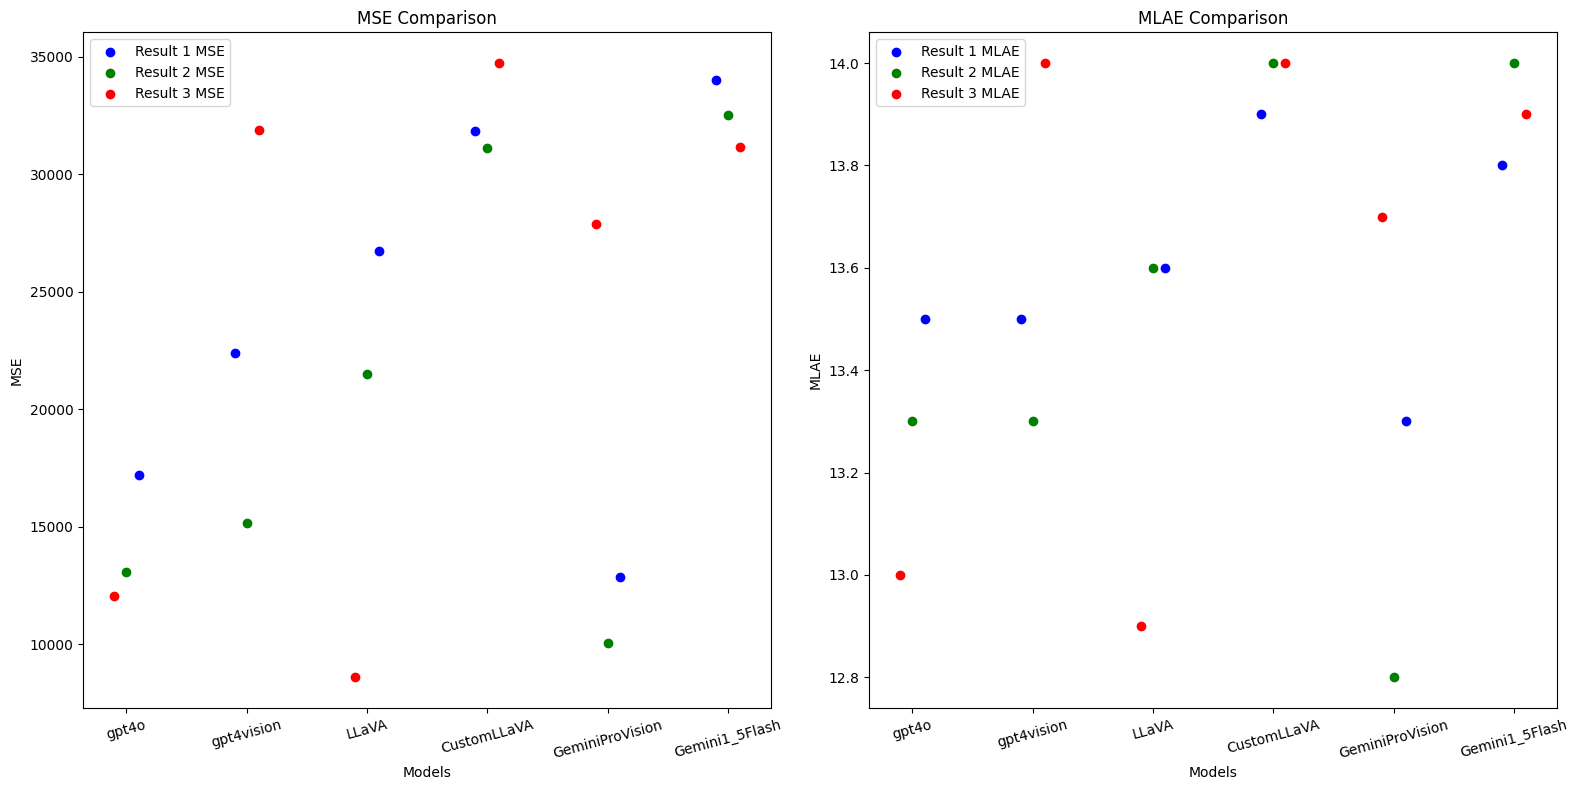

In [1]:
from plot_model_metrics import plot_charts_metrics

result1={'gt': [236, 94, 271, 6, 328, 331, 13, 72, 157, 61], 'gpt4o': {'raw_answers': ['120-130', '260-270', '80-90', '80-90', '250-260', '80-90', '120-130', '50-60', '70-80', '120-130'], 'parsed_answers': [[120.0, 130.0], [260.0, 270.0], [80.0, 90.0], [80.0, 90.0], [250.0, 260.0], [80.0, 90.0], [120.0, 130.0], [50.0, 60.0], [70.0, 80.0], [120.0, 130.0]], 'mean': 128.0, 'std': 69.72087205421343, 'mse': 17189.7, 'mlae': 13.478026976249865, 'times': [5875.471353530884, 7557.029247283936, 5650.092124938965, 5988.2402420043945, 8898.521661758423, 5674.267053604126, 6034.302711486816, 6100.896835327148, 5704.391002655029, 5612.676382064819], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['310-320', '270-280', '180-190', '90-100', '45-55', '45-55', '45-55', '45-55', '45-55', '45-55'], 'parsed_answers': [[310.0, 320.0], [270.0, 280.0], [180.0, 190.0], [90.0, 100.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0]], 'mean': 117.0, 'std': 98.08669634563088, 'mse': 22398.7, 'mlae': 13.515468855552335, 'times': [6235.499858856201, 6550.948619842529, 5817.669868469238, 5783.199787139893, 5991.6956424713135, 5820.788621902466, 7636.152982711792, 5869.818449020386, 5875.295400619507, 6079.349994659424], 'forced_repetitions': 0}, 'LLaVA': {'raw_answers': ['Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.', 'Yes, I see a line in the image. The line is approximately 45 degrees.', 'Yes, I see a line in the image. The line is pointing upwards, and I estimate its direction to be approximately 45 degrees.', 'Yes, I see a line in the image. The line is pointing upwards, and I can estimate its direction in degrees as approximately 45-55 degrees.', 'Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.', 'Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.', 'Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.', 'Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.', 'Yes, I see a line in the image. The line is pointing upwards, and I can estimate its direction in degrees as approximately 45-55 degrees.', 'Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.'], 'parsed_answers': [[45.0], [45.0], [45.0], [45.0, 55.0], [45.0], [45.0], [45.0], [45.0], [45.0, 55.0], [45.0]], 'mean': 46.0, 'std': 2.0, 'mse': 26723.7, 'mlae': 13.622294956245424, 'times': [11154.870986938477, 10866.340160369873, 11164.198637008667, 11393.059253692627, 11078.396320343018, 11135.442018508911, 11373.06809425354, 11089.388608932495, 11176.120281219482, 11346.05598449707], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['26', '20', '11', '56', '26', '44', '80', '10', '37', '12'], 'parsed_answers': [[26.0], [20.0], [11.0], [56.0], [26.0], [44.0], [80.0], [10.0], [37.0], [12.0]], 'mean': 32.2, 'std': 21.423351745233514, 'mse': 31838.3, 'mlae': 13.854296196821657, 'times': [9454.687356948853, 9211.17377281189, 9265.254497528076, 9460.690259933472, 9516.061067581177, 9243.554592132568, 9977.38003730774, 9258.336782455444, 9600.250482559204, 9296.51951789856], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['260-270 \n', '260-270 \n', '260-270 \n', '135-145 \n', '260-270 \n', '260-270 \n', '135-145 \n', '260-270 \n', '265-275 \n', '135-145 \n'], 'parsed_answers': [[260.0, 270.0], [260.0, 270.0], [260.0, 270.0], [135.0, 145.0], [260.0, 270.0], [260.0, 270.0], [135.0, 145.0], [260.0, 270.0], [265.0, 275.0], [135.0, 145.0]], 'mean': 228.0, 'std': 57.62811813689564, 'mse': 12878.7, 'mlae': 13.260055803953817, 'times': [5884.856939315796, 5820.269346237183, 5800.946950912476, 5778.3002853393555, 5733.4630489349365, 5671.504974365234, 5707.935571670532, 6280.440330505371, 5675.588369369507, 5680.624961853027], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['90-100 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n'], 'parsed_answers': [[90.0, 100.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0]], 'mean': 14.0, 'std': 27.0, 'mse': 33995.7, 'mlae': 13.802730915723654, 'times': [5317.862510681152, 5382.599115371704, 10600.365400314331, 10636.071920394897, 5354.639768600464, 5424.29256439209, 5425.35400390625, 5306.910991668701, 5392.867565155029, 5351.43518447876], 'forced_repetitions': 2}}
result2={'gt': [230, 152, 183, 113, 247, 64, 209, 292, 176, 67], 'gpt4o': {'raw_answers': ['120-130', '30-40', '90-100', '120-130', '60-70', '80-90', '40-50', '120-130', '90-100', '120-130'], 'parsed_answers': [[120.0, 130.0], [30.0, 40.0], [90.0, 100.0], [120.0, 130.0], [60.0, 70.0], [80.0, 90.0], [40.0, 50.0], [120.0, 130.0], [90.0, 100.0], [120.0, 130.0]], 'mean': 92.0, 'std': 32.57299494980466, 'mse': 13087.7, 'mlae': 13.280498934514087, 'times': [5752.084732055664, 5728.010416030884, 5733.410835266113, 5884.1540813446045, 6132.838249206543, 6029.208660125732, 5709.424257278442, 5708.197355270386, 5791.329622268677, 5796.098709106445], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['45-55', '315-325', '90-100', '310-320', '310-320', '45-55', '40-50', '310-320', '270-280', '45-55'], 'parsed_answers': [[45.0, 55.0], [315.0, 325.0], [90.0, 100.0], [310.0, 320.0], [310.0, 320.0], [45.0, 55.0], [40.0, 50.0], [310.0, 320.0], [270.0, 280.0], [45.0, 55.0]], 'mean': 183.0, 'std': 126.237870704476, 'mse': 15150.7, 'mlae': 13.320536152763518, 'times': [5940.471172332764, 6057.368516921997, 5852.69021987915, 5855.979204177856, 5908.656597137451, 6014.019727706909, 5873.0292320251465, 5970.751047134399, 5811.859130859375, 6152.969598770142], 'forced_repetitions': 0}, 'LLaVA': {'raw_answers': ['Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.', 'Yes, I see a line in the image. The line is pointing upwards, and I can estimate its direction in degrees as approximately 45-55 degrees.', 'Yes, I see a line in the image. The line is approximately 45 degrees.', 'Yes, I see a line in the image. The line is pointing upwards, and I estimate its direction to be approximately 45 degrees.', 'Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.', 'Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.', 'Yes, I see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.', 'Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.', 'Yes, I see a line in the image. The line is oriented at approximately 45 degrees.', 'Yes, I can see a line in the image. The line is pointing upwards, and I estimate its direction to be around 45 degrees.'], 'parsed_answers': [[45.0], [45.0, 55.0], [45.0], [45.0], [45.0], [45.0], [45.0], [45.0], [45.0], [45.0]], 'mean': 45.5, 'std': 1.5, 'mse': 21501.2, 'mlae': 13.641614326632338, 'times': [14410.094022750854, 13330.262899398804, 11699.14698600769, 11679.955959320068, 11683.49838256836, 11976.195573806763, 11721.679210662842, 11745.137929916382, 11570.20902633667, 11758.201837539673], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['13', '11', '2', '13', '12', '34', '11', '15', '14', '10'], 'parsed_answers': [[13.0], [11.0], [2.0], [13.0], [12.0], [34.0], [11.0], [15.0], [14.0], [10.0]], 'mean': 13.5, 'std': 7.632168761236874, 'mse': 31128.2, 'mlae': 13.96399107293266, 'times': [10287.771940231323, 9342.345714569092, 9610.612392425537, 9301.378011703491, 9371.667861938477, 9446.812868118286, 9561.488151550293, 9496.65904045105, 9376.414060592651, 9253.25870513916], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['260-270 \n', '135-145 \n', '135-145 \n', '135-145 \n', '265-275 \n', '265-275 \n', '135-145 \n', '260-270 \n', '265-275 \n', '260-270 \n'], 'parsed_answers': [[260.0, 270.0], [135.0, 145.0], [135.0, 145.0], [135.0, 145.0], [265.0, 275.0], [265.0, 275.0], [135.0, 145.0], [260.0, 270.0], [265.0, 275.0], [260.0, 270.0]], 'mean': 216.5, 'std': 62.49199948793445, 'mse': 10044.2, 'mlae': 12.841588916578608, 'times': [5914.557933807373, 5725.555658340454, 5749.862432479858, 5754.806995391846, 5705.352067947388, 5745.8953857421875, 5886.215925216675, 5709.649562835693, 5684.674501419067, 5684.557199478149], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['0-10 \n', '270-280 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '90-100 \n'], 'parsed_answers': [[0.0, 10.0], [270.0, 280.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [90.0, 100.0]], 'mean': 41.0, 'std': 82.48636250920512, 'mse': 32515.7, 'mlae': 13.98816319530202, 'times': [5325.326681137085, 5354.086399078369, 5334.746599197388, 5349.897623062134, 5387.241840362549, 5327.760219573975, 5541.295051574707, 5396.667242050171, 26660.236597061157, 5314.16130065918], 'forced_repetitions': 4}}
result3={'gt': [129, 229, 187, 28, 27, 234, 124, 210, 323, 259], 'gpt4o': {'raw_answers': ['120-130', '30-40', '80-90', '50-60', '50-60', '120-130', '110-120', '60-70', '300-310', '60-70'], 'parsed_answers': [[120.0, 130.0], [30.0, 40.0], [80.0, 90.0], [50.0, 60.0], [50.0, 60.0], [120.0, 130.0], [110.0, 120.0], [60.0, 70.0], [300.0, 310.0], [60.0, 70.0]], 'mean': 103.0, 'std': 73.72923436466705, 'mse': 12051.6, 'mlae': 13.018917348292995, 'times': [727.0815372467041, 1072.218418121338, 742.847204208374, 973.5305309295654, 693.0363178253174, 929.3386936187744, 665.1058197021484, 690.9255981445312, 821.6719627380371, 820.3120231628418], 'forced_repetitions': 0}, 'gpt4vision': {'raw_answers': ['330-340', '45-55', '90-100', '45-55', '45-55', '45-55', '310-320', '45-55', '45-55', '0-10'], 'parsed_answers': [[330.0, 340.0], [45.0, 55.0], [90.0, 100.0], [45.0, 55.0], [45.0, 55.0], [45.0, 55.0], [310.0, 320.0], [45.0, 55.0], [45.0, 55.0], [0.0, 10.0]], 'mean': 105.0, 'std': 111.91514642799696, 'mse': 31893.6, 'mlae': 13.951296099826099, 'times': [924.135684967041, 865.4072284698486, 1365.3759956359863, 996.9818592071533, 965.0285243988037, 1171.374797821045, 997.2164630889893, 799.4003295898438, 963.1106853485107, 878.8332939147949], 'forced_repetitions': 0}, 'LLaVA': {'raw_answers': ['180-190', '180-190', '180-190', '180-190', '180-190', '180-190', '180-190', '180-190', '180-190', '180-190'], 'parsed_answers': [[180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0], [180.0, 190.0]], 'mean': 185.0, 'std': 0.0, 'mse': 8595.6, 'mlae': 12.899380527033694, 'times': [7857.98716545105, 8114.5195960998535, 7762.953042984009, 7786.753177642822, 7823.362588882446, 7956.639766693115, 7753.776550292969, 7960.180282592773, 7727.005243301392, 7811.809062957764], 'forced_repetitions': 0}, 'CustomLLaVA': {'raw_answers': ['10', '13', '25', '8', '58', '22', '16', '10', '4', '13'], 'parsed_answers': [[10.0], [13.0], [25.0], [8.0], [58.0], [22.0], [16.0], [10.0], [4.0], [13.0]], 'mean': 17.9, 'std': 14.638647478507021, 'mse': 34730.7, 'mlae': 13.995248213694, 'times': [9432.021141052246, 9427.29926109314, 9819.817781448364, 9406.691312789917, 9452.520370483398, 9631.09040260315, 9516.076803207397, 9463.18769454956, 9515.105247497559, 9500.019550323486], 'forced_repetitions': 0}, 'GeminiProVision': {'raw_answers': ['260-270 \n', '260-270 \n', '45-55 \n', '260-270 \n', '310-320 \n', '260-270 \n', '260-270 \n', '260-270 \n', '40-50 \n', '260-270 \n'], 'parsed_answers': [[260.0, 270.0], [260.0, 270.0], [45.0, 55.0], [260.0, 270.0], [310.0, 320.0], [260.0, 270.0], [260.0, 270.0], [260.0, 270.0], [40.0, 50.0], [260.0, 270.0]], 'mean': 226.5, 'std': 90.72072530574256, 'mse': 27886.1, 'mlae': 13.715331960215522, 'times': [756.5188407897949, 737.8766536712646, 654.7553539276123, 707.120418548584, 774.167537689209, 737.0805740356445, 742.722749710083, 763.8721466064453, 694.3678855895996, 710.350513458252], 'forced_repetitions': 0}, 'Gemini1_5Flash': {'raw_answers': ['0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '0-10 \n', '90-100 \n', '0-10 \n', '90-100 \n', '0-10 \n'], 'parsed_answers': [[0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [0.0, 10.0], [90.0, 100.0], [0.0, 10.0], [90.0, 100.0], [0.0, 10.0]], 'mean': 23.0, 'std': 36.0, 'mse': 31149.6, 'mlae': 13.891795567437955, 'times': [293.0793762207031, 293.6546802520752, 308.1357479095459, 318.06397438049316, 368.4353828430176, 345.11256217956543, 349.1048812866211, 308.7642192840576, 312.5879764556885, 299.5727062225342], 'forced_repetitions': 0}}

plot_charts_metrics(result1, result2, result3)